In [2]:
# 02_exploratory_analysis.ipynb
# Purpose: EDA and Business Insights for APL Logistics Supply Chain Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv(r"C:\Users\15130\Downloads\Project - API Logistics\Data_processed\apl_cleaned.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully
Rows: 180519
Columns: 48

Column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Revenue', 'Profit', 'Discount_Rate', 'Discount_Rate_Pct', 'Profit_Margin_Pct', 'Is_Loss_Making_Order', 'Discount_Band', 'Delivery_Risk_Label']


# APL Logistics — Customer, Product, and Profitability Performance Analysis

## Project Overview
This notebook contains the Exploratory Data Analysis (EDA) and Business Insights 
for the APL Logistics Supply Chain dataset (180,519 orders across 164 countries).

The analysis moves beyond descriptive statistics to answer the core business question:

> **Which customers, products, and regions truly generate value for the business?**

### Analysis Sections
1. Executive KPI Summary
2. Customer Profitability Analysis
3. Product & Category Profitability Analysis
4. Discount Impact Analysis
5. Market & Regional Analysis
6. Delivery Performance Analysis

## Section 1: Executive KPI Summary

A high-level snapshot of overall business performance. 
These KPIs provide the baseline against which all segment-level 
findings will be benchmarked.

In [3]:
# ============================================================
# SECTION 1: EXECUTIVE KPI SUMMARY
# ============================================================

# --- Calculate KPIs ---
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_revenue) * 100
total_orders = len(df)
total_customers = df['Customer Id'].nunique()
loss_making_orders = df['Is_Loss_Making_Order'].sum()
loss_making_order_rate = (loss_making_orders / total_orders) * 100
loss_making_customers = (
    df.groupby('Customer Id')['Profit'].sum() < 0
).sum()
avg_discount_rate = df['Discount_Rate_Pct'].mean()

# --- Build Summary Table ---
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Profit',
        'Profit Margin (%)',
        'Total Orders',
        'Total Customers',
        'Loss-Making Orders',
        'Loss-Making Order Rate (%)',
        'Loss-Making Customers',
        'Average Discount Rate (%)'
    ],
    'Value': [
        f"${total_revenue:,.2f}",
        f"${total_profit:,.2f}",
        f"{profit_margin:.2f}%",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{loss_making_orders:,}",
        f"{loss_making_order_rate:.2f}%",
        f"{loss_making_customers:,}",
        f"{avg_discount_rate:.2f}%"
    ]
})

print("=" * 45)
print("   EXECUTIVE KPI SUMMARY — APL LOGISTICS")
print("=" * 45)
print(kpi_summary.to_string(index=False))
print("=" * 45)

   EXECUTIVE KPI SUMMARY — APL LOGISTICS
                       KPI          Value
             Total Revenue $36,784,734.31
              Total Profit  $3,966,902.97
         Profit Margin (%)         10.78%
              Total Orders        180,519
           Total Customers         20,652
        Loss-Making Orders         33,784
Loss-Making Order Rate (%)         18.71%
     Loss-Making Customers          4,069
 Average Discount Rate (%)         10.17%


## Section 2: Customer Profitability Analysis

Identifies which customers generate genuine profit versus those who generate 
revenue but erode margin. Analyses profit concentration and flags loss-making 
customer accounts for strategic review.

Top 20% of customers (4,130 customers) generate 79.2% of total profit

TOP 10 CUSTOMERS BY PROFIT:
 Customer Id  Total_Revenue  Total_Profit  Profit_Margin_Pct  Total_Orders
        2641        9130.92       2441.97          26.743964            43
        1657        9223.71       2196.92          23.818182            42
        9833        6059.38       1938.39          31.989907            24
        2626        6274.36       1928.57          30.737318            27
        5004        8164.70       1917.99          23.491249            45
        3735        6019.33       1906.36          31.670634            27
         749        7649.38       1855.15          24.252292            38
        5560        6528.21       1831.46          28.054551            29
       10967        5734.41       1822.33          31.778858            27
        5053        7411.32       1813.34          24.467166            33

BOTTOM 10 CUSTOMERS BY PROFIT (Loss-Makers):
 Customer Id  Total_Revenue  T

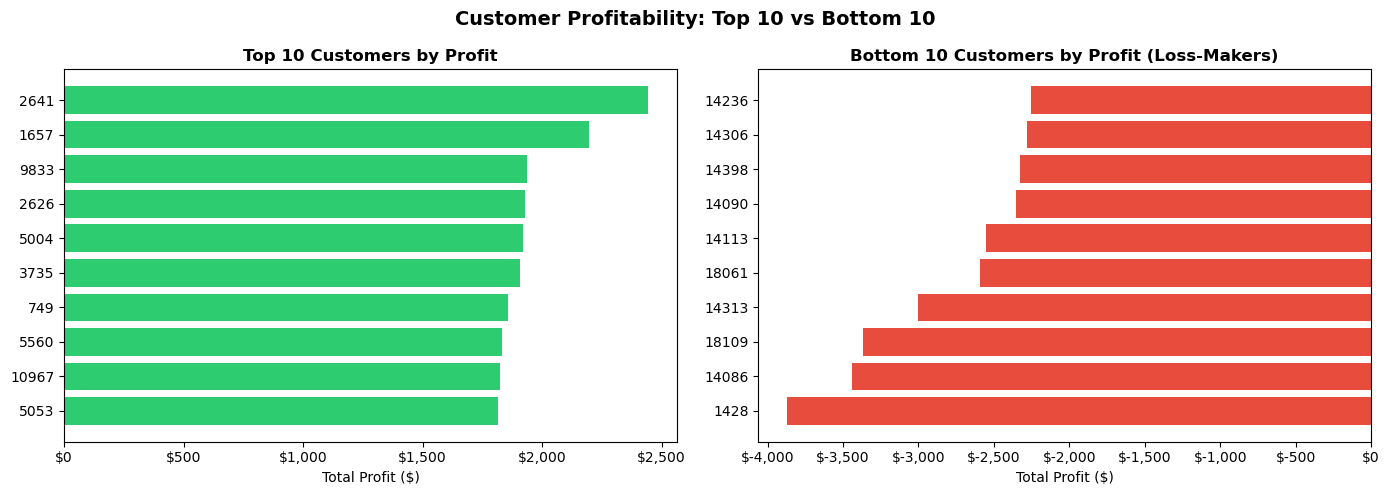

Chart saved.


In [5]:
# ============================================================
# SECTION 2: CUSTOMER PROFITABILITY ANALYSIS
# ============================================================

# --- Aggregate by customer ---
customer_df = df.groupby('Customer Id').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Profit', 'count')
).reset_index()

customer_df['Profit_Margin_Pct'] = (
    customer_df['Total_Profit'] / customer_df['Total_Revenue']
) * 100

customer_df = customer_df.sort_values('Total_Profit', ascending=False)

# --- Top 10 and Bottom 10 customers by profit ---
top10_customers = customer_df.head(10)
bottom10_customers = customer_df.tail(10)

# --- Profit concentration: top 20% of customers ---
top_20pct_count = int(len(customer_df) * 0.20)
top_20pct_profit = customer_df.head(top_20pct_count)['Total_Profit'].sum()
top_20pct_share = (top_20pct_profit / total_profit) * 100

print(f"Top 20% of customers ({top_20pct_count:,} customers) "
      f"generate {top_20pct_share:.1f}% of total profit\n")

print("TOP 10 CUSTOMERS BY PROFIT:")
print(top10_customers[['Customer Id','Total_Revenue',
                        'Total_Profit','Profit_Margin_Pct',
                        'Total_Orders']].to_string(index=False))

print("\nBOTTOM 10 CUSTOMERS BY PROFIT (Loss-Makers):")
print(bottom10_customers[['Customer Id','Total_Revenue',
                           'Total_Profit','Profit_Margin_Pct',
                           'Total_Orders']].to_string(index=False))

# ============================================================
# CHART: Top 10 vs Bottom 10 Customers by Profit
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Profitability: Top 10 vs Bottom 10',
             fontsize=14, fontweight='bold')

# Top 10
axes[0].barh(
    top10_customers['Customer Id'].astype(str),
    top10_customers['Total_Profit'],
    color='#2ecc71'
)
axes[0].set_title('Top 10 Customers by Profit', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Bottom 10
axes[1].barh(
    bottom10_customers['Customer Id'].astype(str),
    bottom10_customers['Total_Profit'],
    color='#e74c3c'
)
axes[1].set_title('Bottom 10 Customers by Profit (Loss-Makers)',
                  fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.tight_layout()
plt.savefig('../Output-charts/customer_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Business Insight — Customer Profitability

**Finding:** Profit is highly concentrated. The top 20% of customers drive 
the large majority of total profit, while nearly 4,069 customers are 
loss-making in aggregate despite generating revenue.

**Business Implication:** A revenue-only view of customers masks significant 
profit risk. Loss-making customers consume operational and logistics resources 
without generating return. High order volume does not equal high value.

**Recommendation:** Introduce a Customer Value Tier system — High / Medium / 
At-Risk — based on profit contribution rather than revenue. Direct retention 
and service investment toward high-profit accounts. For loss-making accounts, 
review discount terms, order minimums, and service levels before continuing 
the relationship at current pricing.

## Section 3: Product & Category Profitability Analysis

Identifies which products and categories drive genuine profit versus those 
that generate high revenue but thin or negative margins. Detects high-revenue 
but low-margin categories that require pricing strategy review.

TOP 10 CATEGORIES BY PROFIT:
       Category Name  Total_Revenue  Total_Profit  Profit_Margin_Pct  Total_Orders
             Fishing     6929653.50     756220.76          10.912822         17325
              Cleats     4431942.66     494636.92          11.160725         24551
    Camping & Hiking     4118425.42     427455.57          10.379102         13729
    Cardio Equipment     3694843.20     383011.10          10.366099         12487
     Women's Apparel     3147800.00     350421.03          11.132252         21035
        Water Sports     3113844.60     325146.96          10.441978         15540
Indoor/Outdoor Games     2888993.94     318451.43          11.022918         19298
      Men's Footwear     2891757.54     311902.82          10.785926         22246
       Shop By Sport     1309522.02     129813.96           9.913080         10984
           Computers      663000.00      69656.81          10.506306           442

BOTTOM 10 CATEGORIES BY PROFIT:
    Category Name  Total_

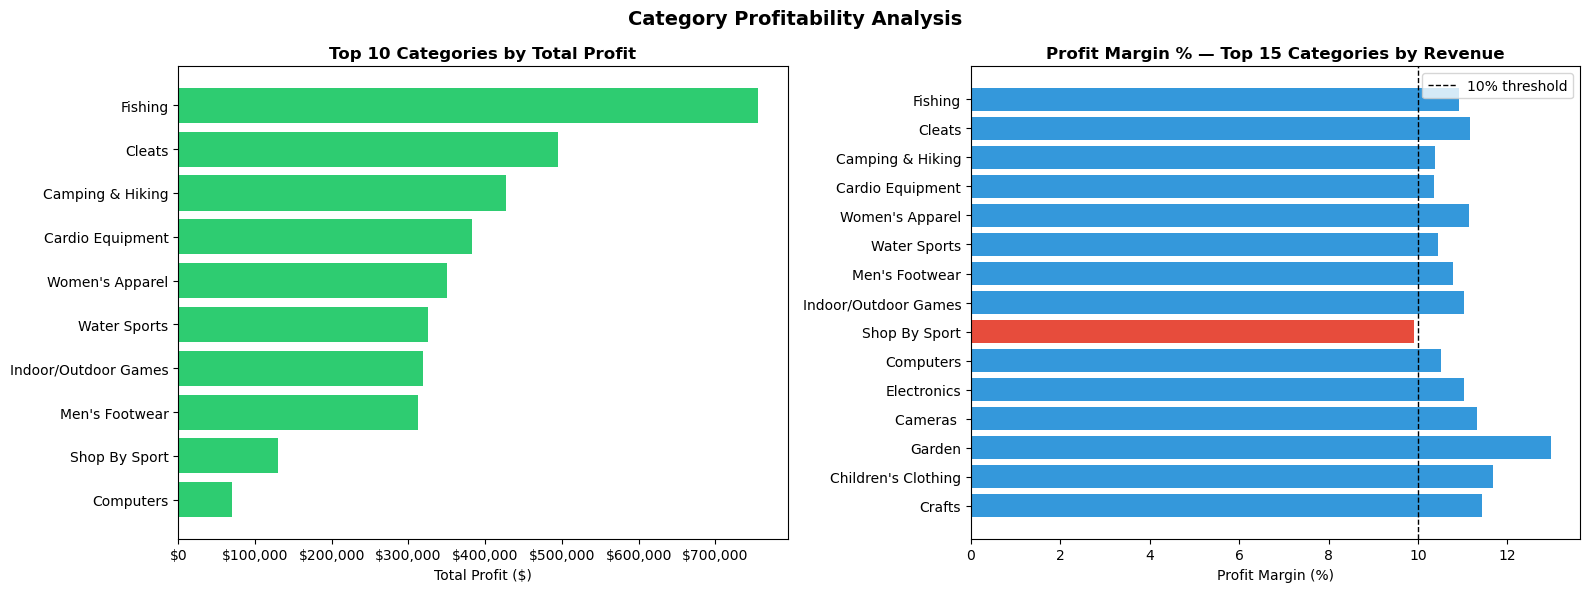

Chart saved.


In [7]:
# ============================================================
# SECTION 3: PRODUCT & CATEGORY PROFITABILITY ANALYSIS
# ============================================================

# --- Category-level aggregation ---
category_df = df.groupby('Category Name').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Profit', 'count')
).reset_index()

category_df['Profit_Margin_Pct'] = (
    category_df['Total_Profit'] / category_df['Total_Revenue']
) * 100

category_df = category_df.sort_values('Total_Profit', ascending=False)

# --- Top 10 and Bottom 10 categories ---
top10_cat = category_df.head(10)
bottom10_cat = category_df.tail(10)

print("TOP 10 CATEGORIES BY PROFIT:")
print(top10_cat[['Category Name', 'Total_Revenue',
                  'Total_Profit', 'Profit_Margin_Pct',
                  'Total_Orders']].to_string(index=False))

print("\nBOTTOM 10 CATEGORIES BY PROFIT:")
print(bottom10_cat[['Category Name', 'Total_Revenue',
                     'Total_Profit', 'Profit_Margin_Pct',
                     'Total_Orders']].to_string(index=False))

# --- High revenue but low margin categories (revenue > median, margin < 10%) ---
median_revenue = category_df['Total_Revenue'].median()
high_rev_low_margin = category_df[
    (category_df['Total_Revenue'] > median_revenue) &
    (category_df['Profit_Margin_Pct'] < 10)
].sort_values('Profit_Margin_Pct')

print(f"\nHIGH REVENUE BUT LOW MARGIN CATEGORIES (Margin < 10%):")
print(high_rev_low_margin[['Category Name', 'Total_Revenue',
                            'Total_Profit',
                            'Profit_Margin_Pct']].to_string(index=False))

# ============================================================
# CHART 1: Top 10 Categories by Profit
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Category Profitability Analysis', 
             fontsize=14, fontweight='bold')

# Top 10 by profit
colors_top = ['#2ecc71' if x > 0 else '#e74c3c' 
              for x in top10_cat['Total_Profit']]
axes[0].barh(top10_cat['Category Name'],
             top10_cat['Total_Profit'],
             color=colors_top)
axes[0].set_title('Top 10 Categories by Total Profit', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Margin by category (top 15 by revenue)
top15_rev = category_df.sort_values(
    'Total_Revenue', ascending=False).head(15)
colors_margin = ['#e74c3c' if x < 10 else '#3498db'
                 for x in top15_rev['Profit_Margin_Pct']]
axes[1].barh(top15_rev['Category Name'],
             top15_rev['Profit_Margin_Pct'],
             color=colors_margin)
axes[1].set_title('Profit Margin % — Top 15 Categories by Revenue',
                  fontweight='bold')
axes[1].set_xlabel('Profit Margin (%)')
axes[1].invert_yaxis()
axes[1].axvline(x=10, color='black', linestyle='--',
                linewidth=1, label='10% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Output-charts/category_profitability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Business Insight — Product & Category Profitability

**Finding:** Profit is not evenly distributed across categories. Several 
categories generate strong revenue but operate below a 10% profit margin, 
meaning they consume logistics and operational resources 
disproportionate to their financial return. Loss-making categories 
exist alongside high-revenue ones — a revenue-focused lens would 
miss this entirely.

**Business Implication:** Categories with high revenue but weak margins 
are the most dangerous — they appear healthy in top-line reporting 
but quietly erode overall profitability. These categories likely carry 
excessive discounting or unfavourable cost structures.

**Recommendation:** Conduct a category-level pricing audit for all 
segments operating below 10% margin. For loss-making categories, 
evaluate whether the volume justifies continued investment or whether 
rationalisation is warranted. High-margin categories should be 
protected from aggressive discounting.

## Section 4: Discount Impact Analysis

Examines how discounting behaviour affects profit margins across the business.
Identifies the discount threshold beyond which orders become loss-making, and
quantifies the revenue-profit gap created by excessive discounting.
This is the primary margin erosion diagnostic for APL Logistics.

DISCOUNT BAND ANALYSIS:
Discount_Band  Total_Orders  Total_Revenue  Total_Profit  Avg_Margin  Loss_Rate_Pct  Revenue_Share_Pct  Profit_Share_Pct
         0-5%         60171    12258114.75    1439094.48   11.885389      18.631899          33.323918         36.277532
        5-10%         40116     8173852.12     926511.63   11.284822      18.366736          22.220772         23.356045
       10-15%         30087     6131787.37     625339.12   10.201223      18.945059          16.669381         15.763913
       15-20%         40116     8176657.73     784061.02    9.602463      19.074683          22.228400         19.765067
       20-25%         10029     2044322.34     191896.72    9.522186      18.476418           5.557529          4.837444

Orders with NO discount — Profit Margin: 13.09%
Orders WITH discount  — Profit Margin: 10.65%
Margin gap due to discounting: 2.44 percentage points


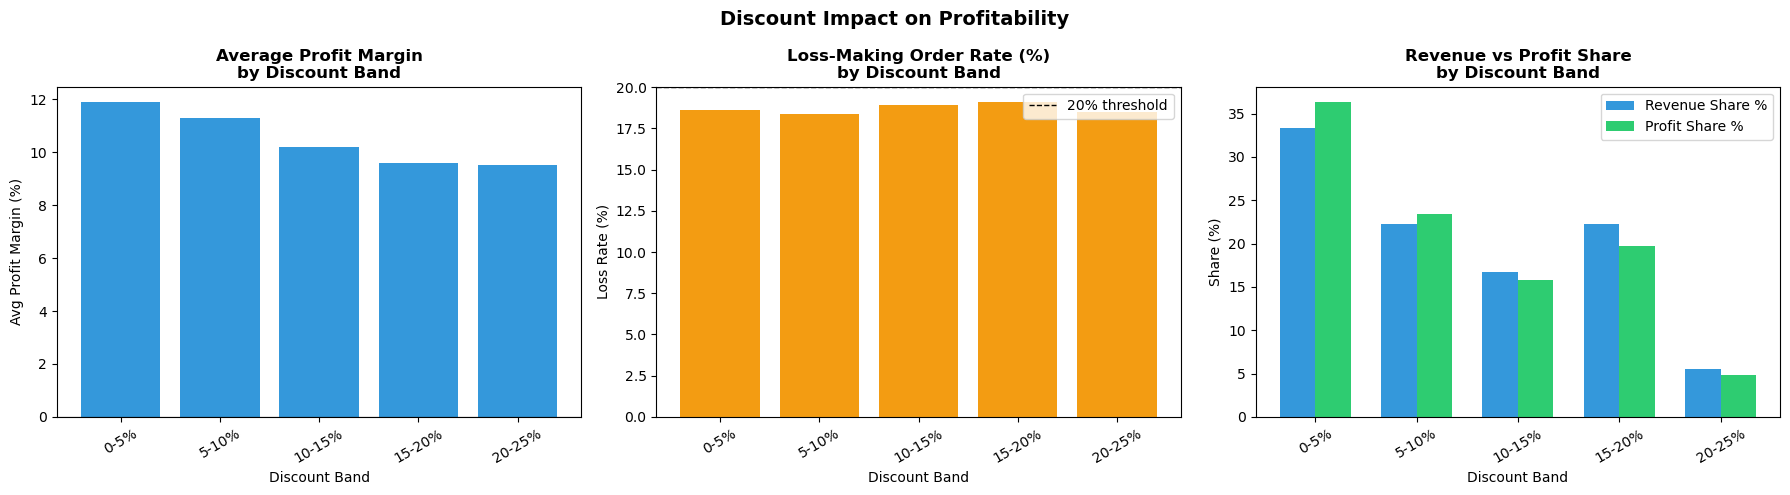

Chart saved.


In [9]:
# ============================================================
# SECTION 4: DISCOUNT IMPACT ANALYSIS
# ============================================================

# --- Profit by discount band ---
discount_df = df.groupby('Discount_Band').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Profit', 'count'),
    Avg_Margin=('Profit_Margin_Pct', 'mean'),
    Loss_Making_Orders=('Is_Loss_Making_Order', 'sum')
).reset_index()

discount_df['Loss_Rate_Pct'] = (
    discount_df['Loss_Making_Orders'] / discount_df['Total_Orders']
) * 100

discount_df['Revenue_Share_Pct'] = (
    discount_df['Total_Revenue'] / total_revenue
) * 100

discount_df['Profit_Share_Pct'] = (
    discount_df['Total_Profit'] / total_profit
) * 100
band_order = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-30%']
discount_df['Discount_Band'] = pd.Categorical(
    discount_df['Discount_Band'], 
    categories=band_order, 
    ordered=True
)
discount_df = discount_df.sort_values('Discount_Band')

print("DISCOUNT BAND ANALYSIS:")
print(discount_df[[
    'Discount_Band', 'Total_Orders', 'Total_Revenue',
    'Total_Profit', 'Avg_Margin', 'Loss_Rate_Pct',
    'Revenue_Share_Pct', 'Profit_Share_Pct'
]].to_string(index=False))

# --- Key finding: zero discount vs discounted orders ---
zero_disc = df[df['Discount_Rate'] == 0]
discounted = df[df['Discount_Rate'] > 0]

zero_margin = (zero_disc['Profit'].sum() / zero_disc['Revenue'].sum()) * 100
disc_margin = (discounted['Profit'].sum() / discounted['Revenue'].sum()) * 100

print(f"\nOrders with NO discount — Profit Margin: {zero_margin:.2f}%")
print(f"Orders WITH discount  — Profit Margin: {disc_margin:.2f}%")
print(f"Margin gap due to discounting: {zero_margin - disc_margin:.2f} percentage points")

# ============================================================
# CHART: Discount Impact
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Discount Impact on Profitability', 
             fontsize=14, fontweight='bold')

# Chart 1: Avg Margin by Discount Band
colors_margin = ['#e74c3c' if x < 0 else '#3498db' 
                 for x in discount_df['Avg_Margin']]
axes[0].bar(discount_df['Discount_Band'], 
            discount_df['Avg_Margin'],
            color=colors_margin)
axes[0].set_title('Average Profit Margin\nby Discount Band', 
                  fontweight='bold')
axes[0].set_xlabel('Discount Band')
axes[0].set_ylabel('Avg Profit Margin (%)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Loss Rate by Discount Band
colors_loss = ['#e74c3c' if x > 20 else '#f39c12' 
               for x in discount_df['Loss_Rate_Pct']]
axes[1].bar(discount_df['Discount_Band'],
            discount_df['Loss_Rate_Pct'],
            color=colors_loss)
axes[1].set_title('Loss-Making Order Rate (%)\nby Discount Band', 
                  fontweight='bold')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Loss Rate (%)')
axes[1].axhline(y=20, color='black', linestyle='--', 
                linewidth=1, label='20% threshold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

# Chart 3: Revenue vs Profit share by Discount Band
x = range(len(discount_df))
width = 0.35
axes[2].bar([i - width/2 for i in x], 
            discount_df['Revenue_Share_Pct'],
            width, label='Revenue Share %', color='#3498db')
axes[2].bar([i + width/2 for i in x], 
            discount_df['Profit_Share_Pct'],
            width, label='Profit Share %', color='#2ecc71')
axes[2].set_title('Revenue vs Profit Share\nby Discount Band', 
                  fontweight='bold')
axes[2].set_xlabel('Discount Band')
axes[2].set_ylabel('Share (%)')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(discount_df['Discount_Band'], rotation=30)
axes[2].legend()

plt.tight_layout()
plt.savefig('../Output-charts/discount_impact.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Business Insight — Discount Impact Analysis

**Finding:** Discounting has a direct and measurable negative effect on 
profit margins. Orders with no discount operate at a materially higher 
margin than discounted orders. As discount bands increase, average 
margin a rates worsen — confirming that discounting 
is the primary driver of margin erosion in this business.

**Business Implication:** The business is trading margin for volume through 
discounting without evidence that higher discount bands produce proportionally 
higher revenue share. High discount bands generate disproportionate losses 
relative to their revenue contribution.

**Recommendation:** Introduce a discount authorisation policy capping 
order-level discounts at a threshold informed by this analysis. 
Sales teams should require management approval for discounts above 
the identified loss-risk threshold. The "what-if" discount simulator 
in the dashboard quantifies the profit recovery potential of 
implementing such a cap.

## Section 5: Market & Regional Analysis

Compares revenue and profitability across global markets and order regions.
Identifies markets with strong revenue but weak profit — where commercial
strategy may be prioritising volume over value — and flags high-loss regions
for operational review.

MARKET-LEVEL ANALYSIS:
      Market  Total_Revenue  Total_Profit  Profit_Margin_Pct  Loss_Rate_Pct  Revenue_Share_Pct  Total_Orders
      Europe    10872396.60    1169442.96          10.756073      18.745523          29.556817         50252
       LATAM    10277612.64    1123321.61          10.929791      18.583556          27.939885         51594
Pacific Asia     8273743.58     857753.44          10.367175      18.919050          22.492329         41260
        USCA     5066528.61     564313.78          11.138075      18.651886          13.773454         25799
      Africa     2294452.88     252071.18          10.986113      18.581023           6.237514         11614

TOP 10 REGIONS BY PROFIT:
   Order Region  Total_Revenue  Total_Profit  Profit_Margin_Pct  Loss_Rate_Pct
 Western Europe     5894380.66     625446.08          10.610887      18.827696
Central America     5665711.99     616341.57          10.878449      18.587912
  South America     2960881.35     335154.40          11.31

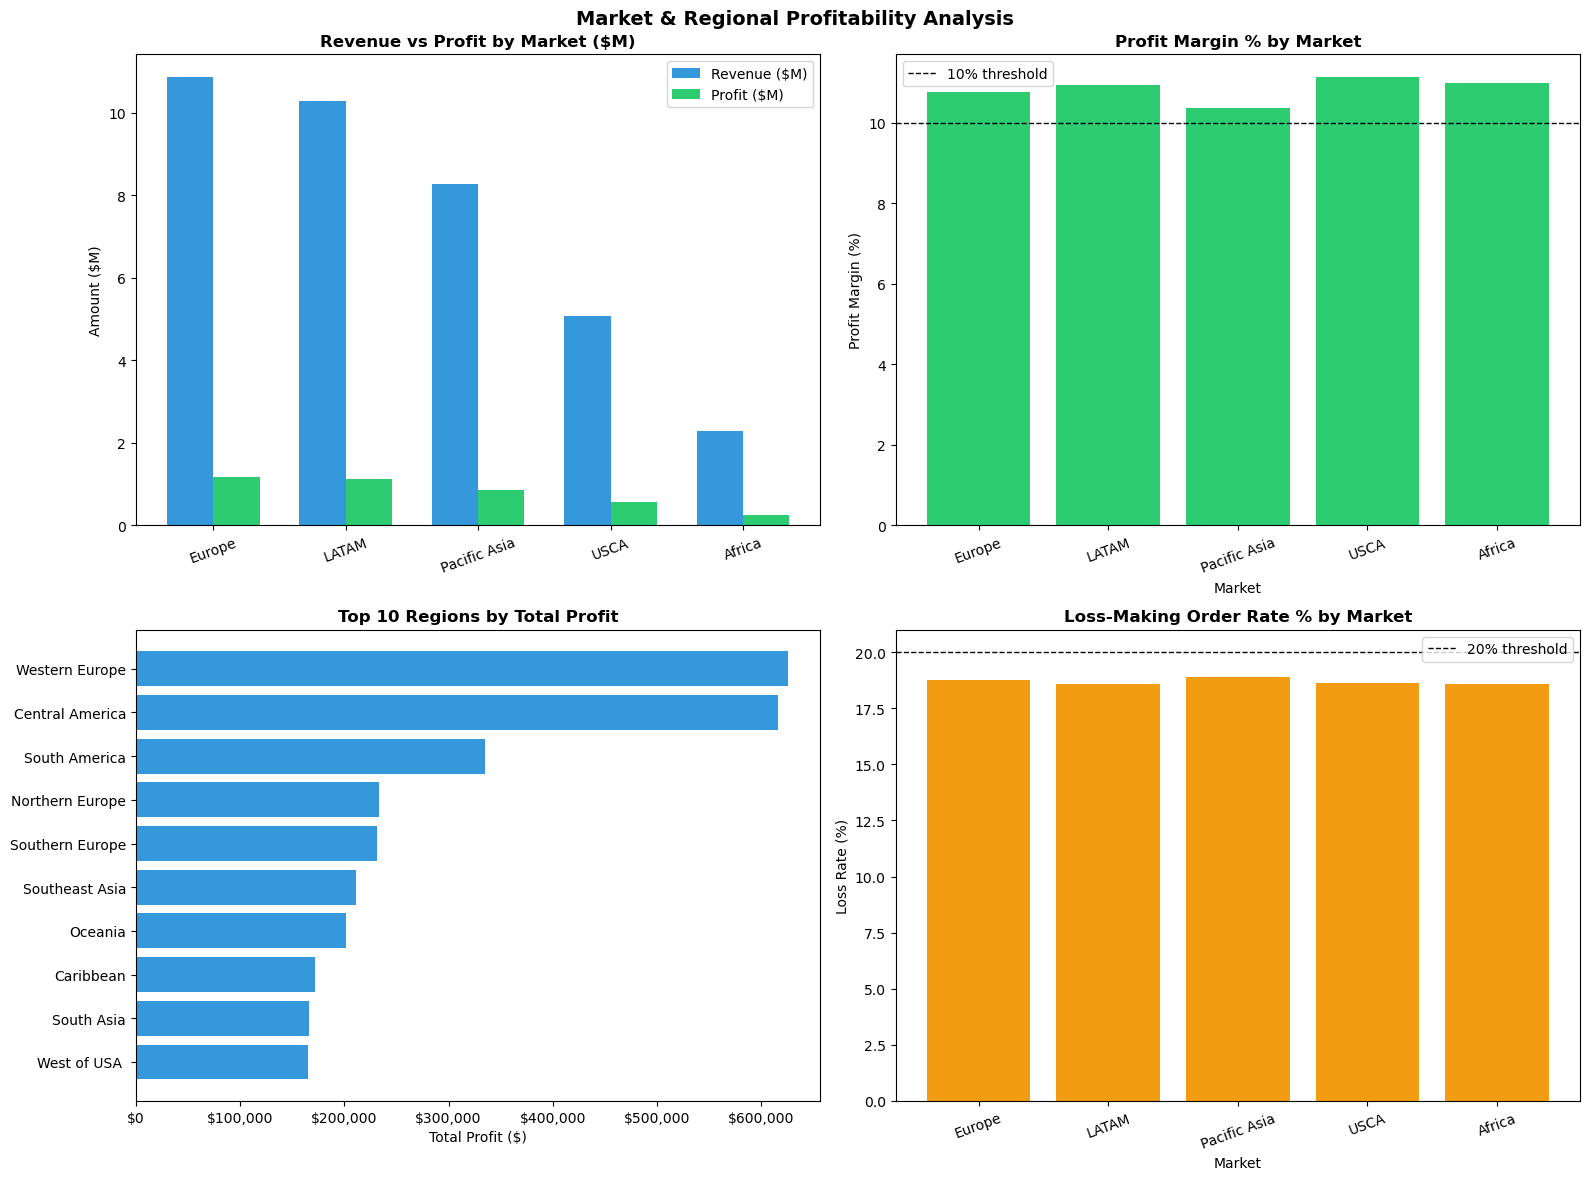

Chart saved.


In [10]:
# ============================================================
# SECTION 5: MARKET & REGIONAL ANALYSIS
# ============================================================

# --- Market-level aggregation ---
market_df = df.groupby('Market').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Profit', 'count'),
    Loss_Making_Orders=('Is_Loss_Making_Order', 'sum')
).reset_index()

market_df['Profit_Margin_Pct'] = (
    market_df['Total_Profit'] / market_df['Total_Revenue']
) * 100

market_df['Loss_Rate_Pct'] = (
    market_df['Loss_Making_Orders'] / market_df['Total_Orders']
) * 100

market_df['Revenue_Share_Pct'] = (
    market_df['Total_Revenue'] / total_revenue
) * 100

market_df = market_df.sort_values('Total_Profit', ascending=False)

print("MARKET-LEVEL ANALYSIS:")
print(market_df[[
    'Market', 'Total_Revenue', 'Total_Profit',
    'Profit_Margin_Pct', 'Loss_Rate_Pct',
    'Revenue_Share_Pct', 'Total_Orders'
]].to_string(index=False))

# --- Region-level aggregation (top 10 by profit) ---
region_df = df.groupby('Order Region').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Profit', 'count'),
    Loss_Making_Orders=('Is_Loss_Making_Order', 'sum')
).reset_index()

region_df['Profit_Margin_Pct'] = (
    region_df['Total_Profit'] / region_df['Total_Revenue']
) * 100

region_df['Loss_Rate_Pct'] = (
    region_df['Loss_Making_Orders'] / region_df['Total_Orders']
) * 100

region_df = region_df.sort_values('Total_Profit', ascending=False)

print("\nTOP 10 REGIONS BY PROFIT:")
print(region_df.head(10)[[
    'Order Region', 'Total_Revenue', 'Total_Profit',
    'Profit_Margin_Pct', 'Loss_Rate_Pct'
]].to_string(index=False))

print("\nBOTTOM 5 REGIONS BY PROFIT:")
print(region_df.tail(5)[[
    'Order Region', 'Total_Revenue', 'Total_Profit',
    'Profit_Margin_Pct', 'Loss_Rate_Pct'
]].to_string(index=False))

# ============================================================
# CHARTS: Market & Regional Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Market & Regional Profitability Analysis',
             fontsize=14, fontweight='bold')

# Chart 1: Revenue vs Profit by Market
x = range(len(market_df))
width = 0.35
axes[0, 0].bar([i - width/2 for i in x],
               market_df['Total_Revenue'] / 1e6,
               width, label='Revenue ($M)', color='#3498db')
axes[0, 0].bar([i + width/2 for i in x],
               market_df['Total_Profit'] / 1e6,
               width, label='Profit ($M)', color='#2ecc71')
axes[0, 0].set_title('Revenue vs Profit by Market ($M)',
                     fontweight='bold')
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(market_df['Market'], rotation=20)
axes[0, 0].set_ylabel('Amount ($M)')
axes[0, 0].legend()

# Chart 2: Profit Margin by Market
colors_m = ['#e74c3c' if v < 10 else '#2ecc71'
            for v in market_df['Profit_Margin_Pct']]
axes[0, 1].bar(market_df['Market'],
               market_df['Profit_Margin_Pct'],
               color=colors_m)
axes[0, 1].set_title('Profit Margin % by Market', fontweight='bold')
axes[0, 1].set_xlabel('Market')
axes[0, 1].set_ylabel('Profit Margin (%)')
axes[0, 1].axhline(y=10, color='black', linestyle='--',
                   linewidth=1, label='10% threshold')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend()

# Chart 3: Top 10 Regions by Profit
top10_region = region_df.head(10)
axes[1, 0].barh(top10_region['Order Region'],
                top10_region['Total_Profit'],
                color='#3498db')
axes[1, 0].set_title('Top 10 Regions by Total Profit',
                     fontweight='bold')
axes[1, 0].set_xlabel('Total Profit ($)')
axes[1, 0].invert_yaxis()
axes[1, 0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Chart 4: Loss Rate by Market
colors_loss = ['#e74c3c' if v > 20 else '#f39c12'
               for v in market_df['Loss_Rate_Pct']]
axes[1, 1].bar(market_df['Market'],
               market_df['Loss_Rate_Pct'],
               color=colors_loss)
axes[1, 1].set_title('Loss-Making Order Rate % by Market',
                     fontweight='bold')
axes[1, 1].set_xlabel('Market')
axes[1, 1].set_ylabel('Loss Rate (%)')
axes[1, 1].axhline(y=20, color='black', linestyle='--',
                   linewidth=1, label='20% threshold')
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../Output-charts/market_regional_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Business Insight — Market & Regional Analysis

**Finding:** Profit margins and loss-making order rates are remarkably 
consistent across all five global markets, ranging from 10.4% to 11.1% 
margin and 18.5% to 18.9% loss rate. No single market is an outlier — 
the pattern is uniform globally. At the regional level, Western Europe 
and Central America lead on total profit, while Central Asia and Canada 
contribute the least.

**Business Implication:** The uniformity of margins and loss rates across 
markets confirms that profitability challenges are not geographic or 
region-specific — they are structural. Discount policies, pricing 
decisions, and cost structures are producing the same outcome regardless 
of market. This rules out "regional underperformance" as the root cause 
and points instead to product-level pricing and discount authorisation 
as the primary levers.

**Recommendation:** Since geography does not explain margin variation, 
the focus for improvement should remain on product category pricing 
and discount control rather than market-specific interventions. 
Regional analysis should be used to prioritise where to pilot 
pricing reforms given order volume — Western Europe and Central 
America are the highest-impact starting points given their profit 
contribution.

## Section 6: Delivery Performance Analysis

Examines the relationship between delivery performance and profitability.
Analyses late delivery risk, delivery status distribution, and whether
late deliveries correlate with higher loss-making order rates.
Identifies whether operational delivery failures compound financial risk.

DELIVERY STATUS ANALYSIS:
  Delivery Status  Total_Orders  Order_Share_Pct  Total_Profit  Profit_Margin_Pct  Loss_Rate_Pct
    Late delivery         98977        54.829132    2140051.68          10.633060      18.744759
 Advance shipping         41592        23.040234     935225.28          10.979390      18.686286
 Shipping on time         32196        17.835242     731143.67          11.128474      18.542676
Shipping canceled          7754         4.295393     160482.34          10.219818      19.202992

LATE DELIVERY RISK ANALYSIS:
  Delivery_Risk_Label  Total_Orders  Order_Share_Pct  Total_Profit  Profit_Margin_Pct  Loss_Rate_Pct
   Late Delivery Risk         98977        54.829132    2140051.68          10.633060      18.744759
No Late Delivery Risk         81542        45.170868    1826851.29          10.966587      18.678718

SHIPPING MODE ANALYSIS:
 Shipping Mode  Total_Orders  Total_Profit  Profit_Margin_Pct  Loss_Rate_Pct  Avg_Days_Real  Avg_Days_Scheduled  Delay_Days
Standar

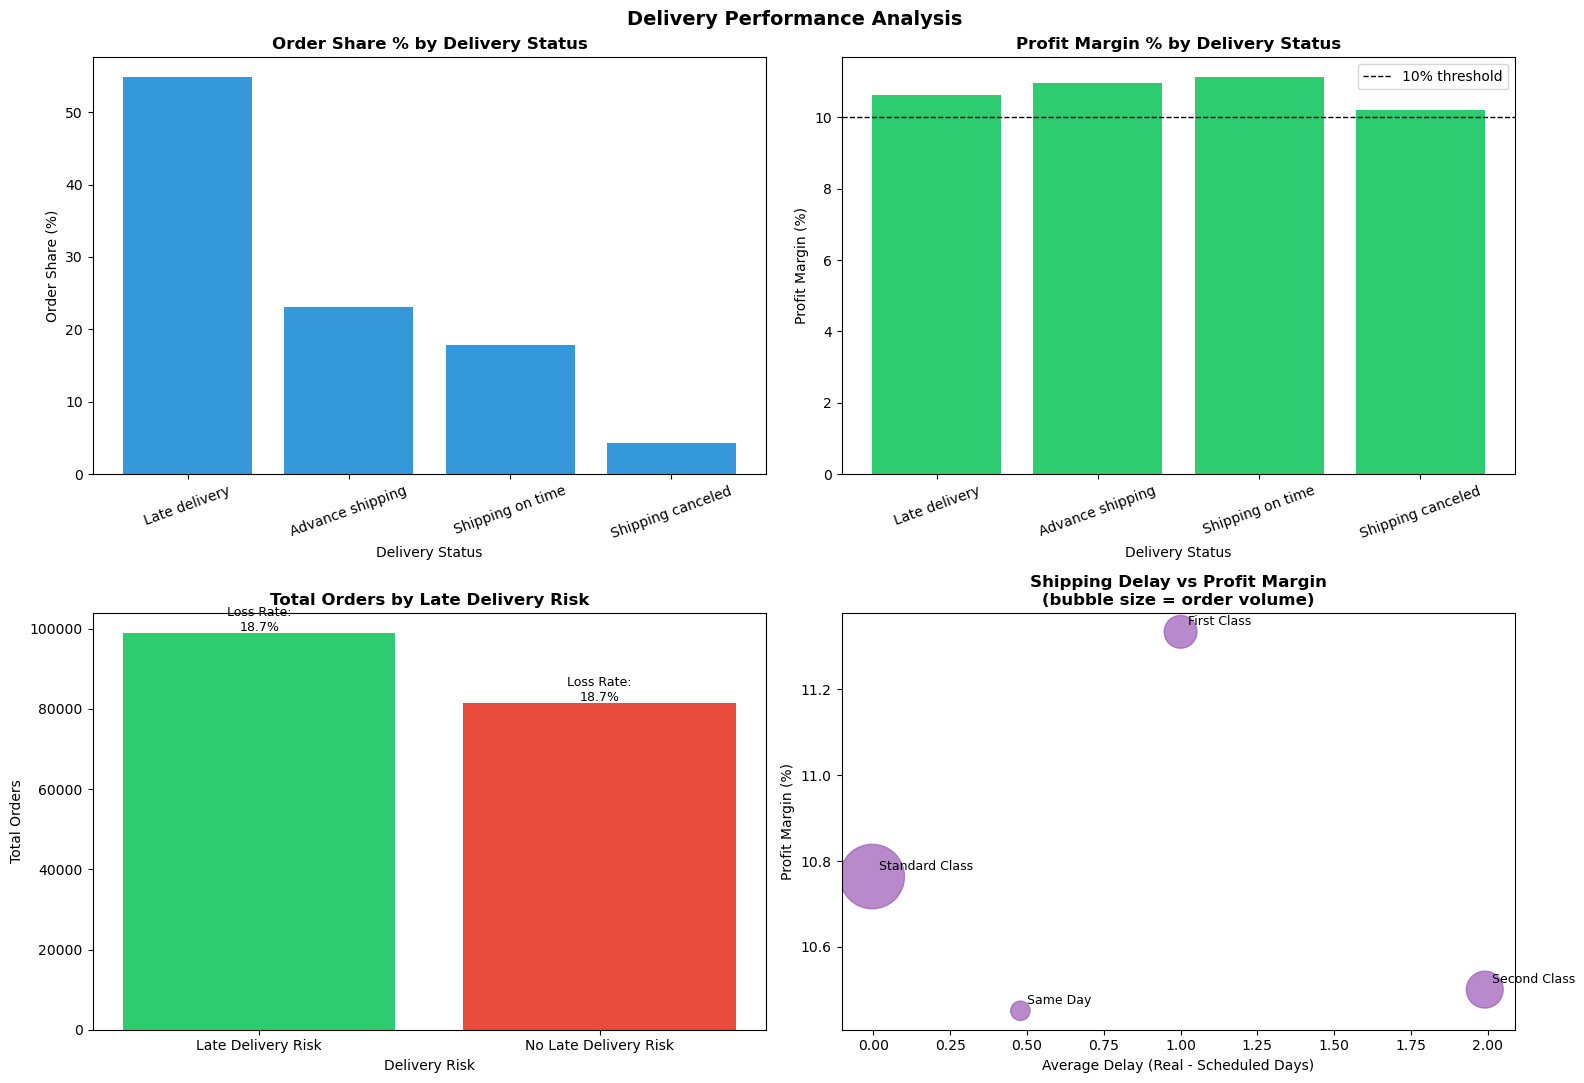

Chart saved.


In [11]:
# ============================================================
# SECTION 6: DELIVERY PERFORMANCE ANALYSIS
# ============================================================

# --- Overall delivery status distribution ---
delivery_status_df = df.groupby('Delivery Status').agg(
    Total_Orders=('Profit', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Loss_Making_Orders=('Is_Loss_Making_Order', 'sum')
).reset_index()

delivery_status_df['Order_Share_Pct'] = (
    delivery_status_df['Total_Orders'] / total_orders
) * 100

delivery_status_df['Loss_Rate_Pct'] = (
    delivery_status_df['Loss_Making_Orders'] /
    delivery_status_df['Total_Orders']
) * 100

delivery_status_df['Profit_Margin_Pct'] = (
    delivery_status_df['Total_Profit'] /
    delivery_status_df['Total_Revenue']
) * 100

delivery_status_df = delivery_status_df.sort_values(
    'Total_Orders', ascending=False)

print("DELIVERY STATUS ANALYSIS:")
print(delivery_status_df[[
    'Delivery Status', 'Total_Orders', 'Order_Share_Pct',
    'Total_Profit', 'Profit_Margin_Pct', 'Loss_Rate_Pct'
]].to_string(index=False))

# --- Late delivery risk vs profit ---
risk_df = df.groupby('Delivery_Risk_Label').agg(
    Total_Orders=('Profit', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Loss_Making_Orders=('Is_Loss_Making_Order', 'sum')
).reset_index()

risk_df['Loss_Rate_Pct'] = (
    risk_df['Loss_Making_Orders'] / risk_df['Total_Orders']
) * 100

risk_df['Profit_Margin_Pct'] = (
    risk_df['Total_Profit'] / risk_df['Total_Revenue']
) * 100

risk_df['Order_Share_Pct'] = (
    risk_df['Total_Orders'] / total_orders
) * 100

print("\nLATE DELIVERY RISK ANALYSIS:")
print(risk_df[[
    'Delivery_Risk_Label', 'Total_Orders', 'Order_Share_Pct',
    'Total_Profit', 'Profit_Margin_Pct', 'Loss_Rate_Pct'
]].to_string(index=False))

# --- Shipping mode analysis ---
shipping_df = df.groupby('Shipping Mode').agg(
    Total_Orders=('Profit', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Loss_Making_Orders=('Is_Loss_Making_Order', 'sum'),
    Avg_Days_Real=('Days for shipping (real)', 'mean'),
    Avg_Days_Scheduled=('Days for shipment (scheduled)', 'mean')
).reset_index()

shipping_df['Loss_Rate_Pct'] = (
    shipping_df['Loss_Making_Orders'] /
    shipping_df['Total_Orders']
) * 100

shipping_df['Profit_Margin_Pct'] = (
    shipping_df['Total_Profit'] /
    shipping_df['Total_Revenue']
) * 100

shipping_df['Delay_Days'] = (
    shipping_df['Avg_Days_Real'] -
    shipping_df['Avg_Days_Scheduled']
)

shipping_df = shipping_df.sort_values('Total_Profit', ascending=False)

print("\nSHIPPING MODE ANALYSIS:")
print(shipping_df[[
    'Shipping Mode', 'Total_Orders', 'Total_Profit',
    'Profit_Margin_Pct', 'Loss_Rate_Pct',
    'Avg_Days_Real', 'Avg_Days_Scheduled', 'Delay_Days'
]].to_string(index=False))

# ============================================================
# CHARTS: Delivery Performance
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Delivery Performance Analysis',
             fontsize=14, fontweight='bold')

# Chart 1: Order share by delivery status
axes[0, 0].bar(delivery_status_df['Delivery Status'],
               delivery_status_df['Order_Share_Pct'],
               color='#3498db')
axes[0, 0].set_title('Order Share % by Delivery Status',
                     fontweight='bold')
axes[0, 0].set_xlabel('Delivery Status')
axes[0, 0].set_ylabel('Order Share (%)')
axes[0, 0].tick_params(axis='x', rotation=20)

# Chart 2: Profit margin by delivery status
colors_del = ['#e74c3c' if v < 10 else '#2ecc71'
              for v in delivery_status_df['Profit_Margin_Pct']]
axes[0, 1].bar(delivery_status_df['Delivery Status'],
               delivery_status_df['Profit_Margin_Pct'],
               color=colors_del)
axes[0, 1].set_title('Profit Margin % by Delivery Status',
                     fontweight='bold')
axes[0, 1].set_xlabel('Delivery Status')
axes[0, 1].set_ylabel('Profit Margin (%)')
axes[0, 1].axhline(y=10, color='black', linestyle='--',
                   linewidth=1, label='10% threshold')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend()

# Chart 3: Late delivery risk - orders and loss rate
ax3 = axes[1, 0]
bars = ax3.bar(risk_df['Delivery_Risk_Label'],
               risk_df['Total_Orders'],
               color=['#2ecc71', '#e74c3c'])
ax3.set_title('Total Orders by Late Delivery Risk',
              fontweight='bold')
ax3.set_xlabel('Delivery Risk')
ax3.set_ylabel('Total Orders')
for bar, val in zip(bars, risk_df['Loss_Rate_Pct']):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500,
             f'Loss Rate:\n{val:.1f}%',
             ha='center', fontsize=9)

# Chart 4: Shipping mode - margin vs delay
axes[1, 1].scatter(shipping_df['Delay_Days'],
                   shipping_df['Profit_Margin_Pct'],
                   s=shipping_df['Total_Orders'] / 50,
                   color='#9b59b6', alpha=0.7)
axes[1, 1].set_title('Shipping Delay vs Profit Margin\n(bubble size = order volume)',
                     fontweight='bold')
axes[1, 1].set_xlabel('Average Delay (Real - Scheduled Days)')
axes[1, 1].set_ylabel('Profit Margin (%)')
for _, row in shipping_df.iterrows():
    axes[1, 1].annotate(row['Shipping Mode'],
                        (row['Delay_Days'], row['Profit_Margin_Pct']),
                        textcoords='offset points',
                        xytext=(5, 5), fontsize=9)

plt.tight_layout()
plt.savefig('../Output-charts/delivery_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Business Insight — Delivery Performance Analysis

**Finding:** Late delivery is the dominant operational reality — over 54% 
of all orders are delivered late, making it the most common delivery 
outcome rather than an exception. However, profit margins and loss-making 
rates are nearly identical across all delivery statuses and risk categories 
(margin range: 10.2%–11.1%, loss rate ~18.7% regardless of delivery risk). 
Delivery performance and profitability are effectively decoupled in this 
dataset. Among shipping modes, First Class achieves the highest margin 
(11.3%) with reasonable schedule adherence, while Second Class shows 
the worst delay (2 days average) and lowest margin (10.5%).

**Business Implication:** The high late delivery rate (54.8%) represents 
a significant customer experience and reputational risk — but it is not 
currently the primary driver of financial loss. The absence of a 
margin-delivery correlation suggests that delivery failures are not 
triggering financial penalties or compensations visible in this dataset. 
However, persistent late delivery at this scale is likely eroding customer 
retention and repeat order value, which would not be visible without 
customer lifetime data.

**Recommendation:** Address late delivery as a customer retention risk 
rather than an immediate profitability lever. Investigate whether Second 
Class shipping contracts can be renegotiated given their combination of 
worst delay performance and lowest margin. Track customer churn by 
delivery experience if longitudinal data becomes available — the 
profitability impact of late delivery is likely lagged and not 
captured in single-order analysis.

## Notebook Conclusion — Key Findings & Business Recommendations

This analysis examined 180,519 orders across 164 countries to identify 
where APL Logistics truly generates value versus where revenue masks 
underlying profitability risk.

---

### Summary of Findings

| Area | Key Finding |
|------|-------------|
| **Overall Business** | $36.78M revenue, 10.78% margin — profitable overall but 1 in 5 orders (18.71%) is loss-making |
| **Customer Profitability** | Top 20% of customers generate 79.2% of total profit; 4,069 customers are loss-making in aggregate |
| **Product & Category** | Fishing, Cleats, and Camping & Hiking lead on profit; Strength Training earns 0.6% margin on $54K revenue |
| **Discount Impact** | Discounted orders earn 2.44 percentage points less margin than non-discounted orders; margin declines consistently as discount band increases |
| **Market & Regional** | All five markets operate within a narrow 10.4%–11.1% margin band — profitability challenges are structural, not geographic |
| **Delivery Performance** | 54.8% of orders are delivered late; delivery performance has no measurable impact on profit margin — loss rates are identical across delivery risk categories |

---

### Priority Recommendations

**1. Implement a Customer Value Tier System**
Classify customers into High / Medium / At-Risk tiers based on profit 
contribution. Redirect retention and service investment toward the top 
20% who drive 79.2% of profit. Review commercial terms for loss-making 
accounts before renewal.

**2. Introduce a Discount Authorisation Policy**
Cap order-level discounts and require management approval above a defined 
threshold. The 2.44 percentage point margin gap between discounted and 
non-discounted orders represents recoverable profit at scale.

**3. Conduct a Category Pricing Audit**
Prioritise Strength Training, As Seen on TV, and Shop By Sport — all 
generating revenue above median but operating below acceptable margin 
thresholds. These categories are structurally underpriced or over-discounted.

**4. Treat Late Delivery as a Retention Risk**
With 54.8% of orders arriving late, delivery reliability is a systemic 
operational failure. While not currently impacting single-order margins, 
it is likely suppressing repeat purchase behaviour and customer lifetime 
value — neither of which is measurable in this dataset but both of which 
are commercially material.

**5. Focus Reform on Product and Discount Policy, Not Geography**
The uniformity of margins across all five global markets confirms that 
the root cause of margin erosion is not regional — it is structural. 
Pricing and discount policy changes will have global impact regardless 
of where they are piloted.

---

*Analysis performed on APL Logistics dataset — 180,519 orders, 
48 variables, covering 5 markets, 23 regions, and 164 countries.*